In [1]:
from collections import Counter, defaultdict
from matplotlib.lines import Line2D
from scipy.spatial import distance
import matplotlib.pyplot as plt
from rdkit import Chem
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import os
import tarfile
import pymol
from pymol import cmd
import matplotlib.image as mpimg
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
from rdkit.Chem.QED import qed
import matplotlib.patches as patches
from matplotlib.colors import to_hex
import subprocess

In [2]:
DOCKING_RESULTS_REAL_2 = {}
DOCKING_RESULTS_ORIGINAL = {}

# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/notebooks'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL_2 = os.path.join(root, "..", "processed", "unidock_REAL_docking_2", 'docking_results')

# Mapping IDs to SMILES
ID_TO_SMILES = pd.read_csv(os.path.join(root, "..", "processed", "unidock_REAL_docking", 'inference_10B', 'clustered_compounds.csv'))
ID_TO_SMILES = {i: j for i,j in zip(ID_TO_SMILES['id'], ID_TO_SMILES['smiles'])}

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))
pocket_detection_data_interpro = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data_interpro.tsv"), sep='\t')

# Uniprot to gene name
uniprot_to_gene = pd.read_csv(os.path.join(root, "..", "data", "mtb_trna_synthetases_bosch_2021_fig5.csv"))
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

# Load pocket coordinates
pocket_to_coords = {}
for file, pocket_numb, coord in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'], pocket_detection_data['Pocket centroid coordinate (x y z)']):
    label = file.replace(".pdb", "") + "_pocket_" + str(pocket_numb)
    pocket_to_coords[label] = np.array(coord.split(), dtype=float)

# For each pocket - REAL 2
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL_2))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL_2, pocket, 'report.csv'))
    assert len(scores) == 99105
    DOCKING_RESULTS_REAL_2[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

100%|██████████| 276/276 [00:12<00:00, 22.54it/s] 


In [3]:
# Define pockets and compounds
POCKETS = sorted(DOCKING_RESULTS_REAL_2)
COMPOUNDS = sorted(DOCKING_RESULTS_REAL_2[POCKETS[0]])

print(f"Number of pockets: {len(POCKETS)}")
print(f"Number of compounds: {len(COMPOUNDS)}")

scores = [DOCKING_RESULTS_REAL_2[pocket][compound] for pocket in POCKETS for compound in COMPOUNDS]
print(f"Average score: {round(np.average(scores), 3)}")
print(f"Percentile 25: {round(np.percentile(scores, 25), 3)}")
print(f"Percentile 5: {round(np.percentile(scores, 5), 3)}")
print(f"Percentile 1: {round(np.percentile(scores, 1), 3)}")
print(f"Percentile 0.1: {round(np.percentile(scores, 0.1), 3)}")
del scores

Number of pockets: 276
Number of compounds: 99105
Average score: -5.445
Percentile 25: -7.795
Percentile 5: -8.848
Percentile 1: -9.67
Percentile 0.1: -10.662


In [4]:
cpd_to_pockets = {}
cpd_to_proteins = {}
pocket_to_cpds = {}
protein_to_cpds = {}

SCORES = [-7, -8, -9, -10, -11, -12]

for SCORE in SCORES:

    cpd_to_pockets[SCORE] = defaultdict(dict)
    cpd_to_proteins[SCORE] = defaultdict(dict)
    pocket_to_cpds[SCORE] = defaultdict(set)
    protein_to_cpds[SCORE] = defaultdict(set)

    for compound in tqdm(COMPOUNDS):
        pockets = set([pocket for pocket in POCKETS if DOCKING_RESULTS_REAL_2[pocket][compound] < SCORE])
        proteins = set([pocket.split("_")[1] for pocket in pockets])
        cpd_to_pockets[SCORE][compound] = pockets
        cpd_to_proteins[SCORE][compound] = proteins
        for pocket in pockets:
            pocket_to_cpds[SCORE][pocket].add(compound)
        for protein in proteins:
            protein_to_cpds[SCORE][protein].add(compound)

100%|██████████| 99105/99105 [00:09<00:00, 10162.60it/s]


In [5]:
hits = [1] + [i for i in range(10, 100_000, 10)]
y_pockets = {}
y_proteins = {}
for score in SCORES:
    y_pockets[score] = list()
    y_proteins[score] = list()
    for N in hits:
        # print(f"Number of pockets with {N}+ hits: {len([i for i in pocket_to_cpds[score] if len(pocket_to_cpds[score][i]) > N])}")
        y_pockets[score].append(len([i for i in pocket_to_cpds[score] if len(pocket_to_cpds[score][i]) > N]))
        y_proteins[score].append(len([i for i in protein_to_cpds[score] if len(protein_to_cpds[score][i]) > N]))

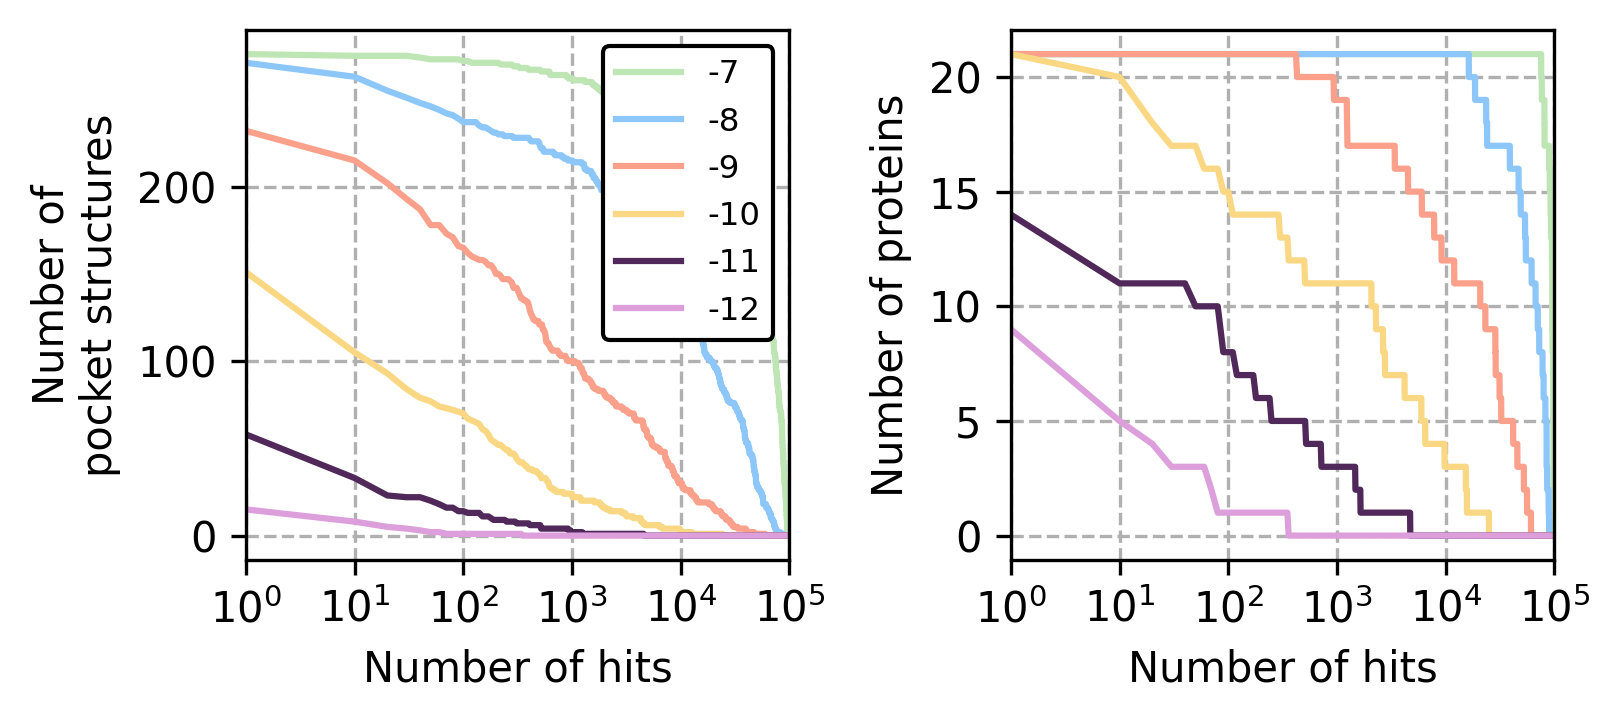

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300)

COLORS= ['#DC9FDC', '#50285A', '#FAD782', '#FAA08B', '#8DC7FA', '#BEE6B4'][::-1]
for score, color in zip(SCORES, COLORS):
    ax[0].plot(hits, y_pockets[score], label=str(score), c=color)
for score, color in zip(SCORES, COLORS):
    ax[1].plot(hits, y_proteins[score], label=str(score), c=color)


ax[0].grid(linestyle='--', zorder=-2)
ax[0].set_ylabel("Number of\npocket structures")
ax[0].set_xlabel("Number of hits")
ax[0].legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 7.8})
ax[0].set_xscale('log')
ax[0].set_xlim([1, 100_000])
ax[0].set_xticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])

ax[1].grid(linestyle='--', zorder=-2)
ax[1].set_xlabel("Number of hits")
ax[1].set_ylabel("Number of proteins")
ax[1].set_xscale('log')
ax[1].set_xlim([1, 100_000])
ax[1].set_xticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])

plt.tight_layout()
plt.show()

In [7]:
print(f"Pocket structures with 100+ hits at score cut-off -10: {y_pockets[-10][np.where(np.array(hits) == 100)[0][0]]}")
print(f"Pocket structures with 1000+ hits at score cut-off -9: {y_pockets[-9][np.where(np.array(hits) == 1000)[0][0]]}")
print(f"Proteins with 100+ hits at score cut-off -10: {y_proteins[-10][np.where(np.array(hits) == 100)[0][0]]}")
print(f"Proteins with 1000+ hits at score cut-off -9: {y_proteins[-9][np.where(np.array(hits) == 1000)[0][0]]}")

Pocket structures with 100+ hits at score cut-off -10: 70
Pocket structures with 1000+ hits at score cut-off -9: 100
Proteins with 100+ hits at score cut-off -10: 15
Proteins with 1000+ hits at score cut-off -9: 19


In [8]:
POCKET_PAIRS = set([tuple(sorted([i,j])) for i in POCKETS for j in POCKETS if i != j])
RESULTS = []
for pocket1, pocket2 in tqdm(POCKET_PAIRS):
    protein1 = pocket1.split("_")[1]
    protein2 = pocket2.split("_")[1]
    same_protein = protein1 == protein2
    same_pocket = False
    if same_protein == True:
        d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])
        if d < 6.14:
            same_pocket = True
    intersection = []
    for score in SCORES:
        cpds1 = pocket_to_cpds[score][pocket1]
        cpds2 = pocket_to_cpds[score][pocket2]
        intersection.append(len(cpds1.intersection(cpds2)))
    RESULTS.append([pocket1, pocket2, same_protein, same_pocket] + intersection)
RESULTS = pd.DataFrame(RESULTS, columns=["pocket1", "pocket2", "same_protein", "same_pocket"] + SCORES)

print(f"Number of pairs: {len(RESULTS)}")
print(f"Same pocket: {len(RESULTS[RESULTS['same_pocket'] == True])}")
print(f"Same protein: {len(RESULTS[(RESULTS['same_pocket'] == False) & (RESULTS['same_protein'] == True)])}")
print(f"Different protein: {len(RESULTS[RESULTS['same_protein'] == False])}")

100%|██████████| 37950/37950 [00:50<00:00, 748.68it/s] 

Number of pairs: 37950
Same pocket: 738
Same protein: 1639
Different protein: 35573


/home/acomajuncosa/miniconda3/envs/adda4tb/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


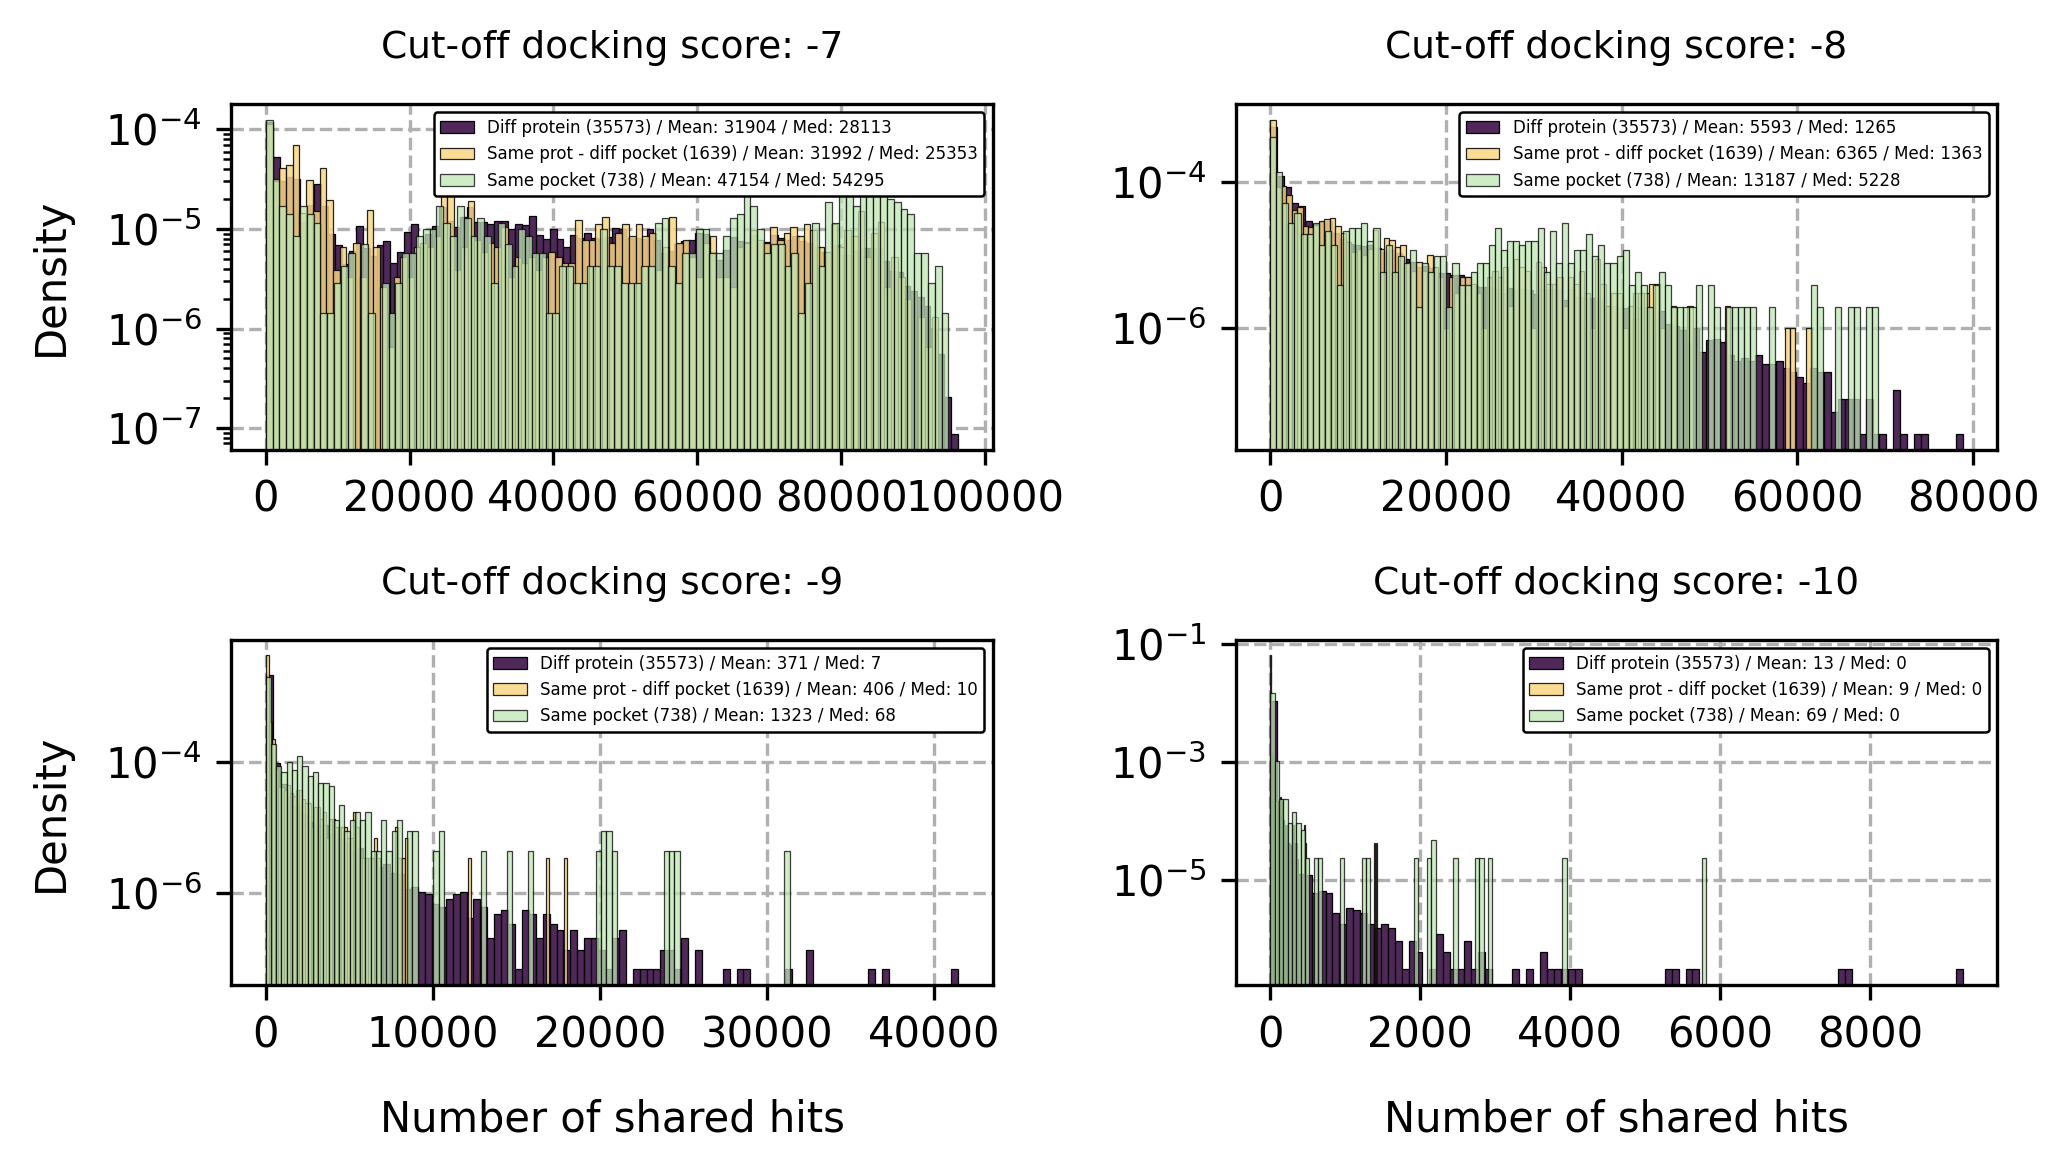

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(7, 4), dpi=300)

for (c1, c2), score in zip([[0,0], [0,1], [1,0], [1,1]], [-7, -8, -9, -10]):

    h1 = RESULTS[RESULTS['same_protein'] == False][score].tolist()
    h2 = RESULTS[(RESULTS['same_protein'] == True) & (RESULTS['same_pocket'] == False)][score].tolist()
    h3 = RESULTS[RESULTS['same_pocket'] == True][score].tolist()

    label1 = f'Diff protein ({len(h1)}) / Mean: {int(np.mean(h1))} / Med: {int(np.median(h1))}'
    label2 = f'Same prot - diff pocket ({len(h2)}) / Mean: {int(np.mean(h2))} / Med: {int(np.median(h2))}'
    label3 = f'Same pocket ({len(h3)}) / Mean: {int(np.mean(h3))} / Med: {int(np.median(h3))}'

    # bins = [i for i in range(0, 100_000, 100)]
    ax[c1][c2].hist(h1, bins=100, density=True, color="#50285A", label=label1, linewidth=0.3, edgecolor='k', zorder=2)
    ax[c1][c2].hist(h2, bins=100, density=True, color="#FAD782", alpha=0.85, label=label2, linewidth=0.3, edgecolor='k', zorder=2)
    ax[c1][c2].hist(h3, bins=100, density=True, color="#BEE6B4", alpha=0.75, label=label3, linewidth=0.3, edgecolor='k', zorder=2)

    l = ax[c1][c2].legend(framealpha=1, edgecolor='k', prop={'size': 4})
    l.get_frame().set_linewidth(0.6)

    ax[c1][c2].set_yscale('log')
    ax[c1][c2].set_title(f"Cut-off docking score: {score}", pad=11, size=9)
    if c1 == 1:
        ax[c1][c2].set_xlabel("Number of shared hits", labelpad=10)
    if c2 == 0:
        ax[c1][c2].set_ylabel("Density", labelpad=8)
    ax[c1][c2].grid(linestyle='--', zorder=-2)

plt.tight_layout()
plt.show()

In [10]:
n_structures = [i for i in range(1, len(POCKETS)+1, 1)]
n_proteins = [i for i in range(1, len(set([i.split("_")[1] for i in POCKETS]))+1, 1)]
y_pockets = {}
y_proteins = {}
for score in SCORES:
    y_pockets[score] = list()
    y_proteins[score] = list()
    for N in n_structures:
        y_pockets[score].append(len([i for i in cpd_to_pockets[score] if len(cpd_to_pockets[score][i]) > N]))
    for N in n_proteins:
        y_proteins[score].append(len([i for i in cpd_to_proteins[score] if len(cpd_to_proteins[score][i]) > N ]))

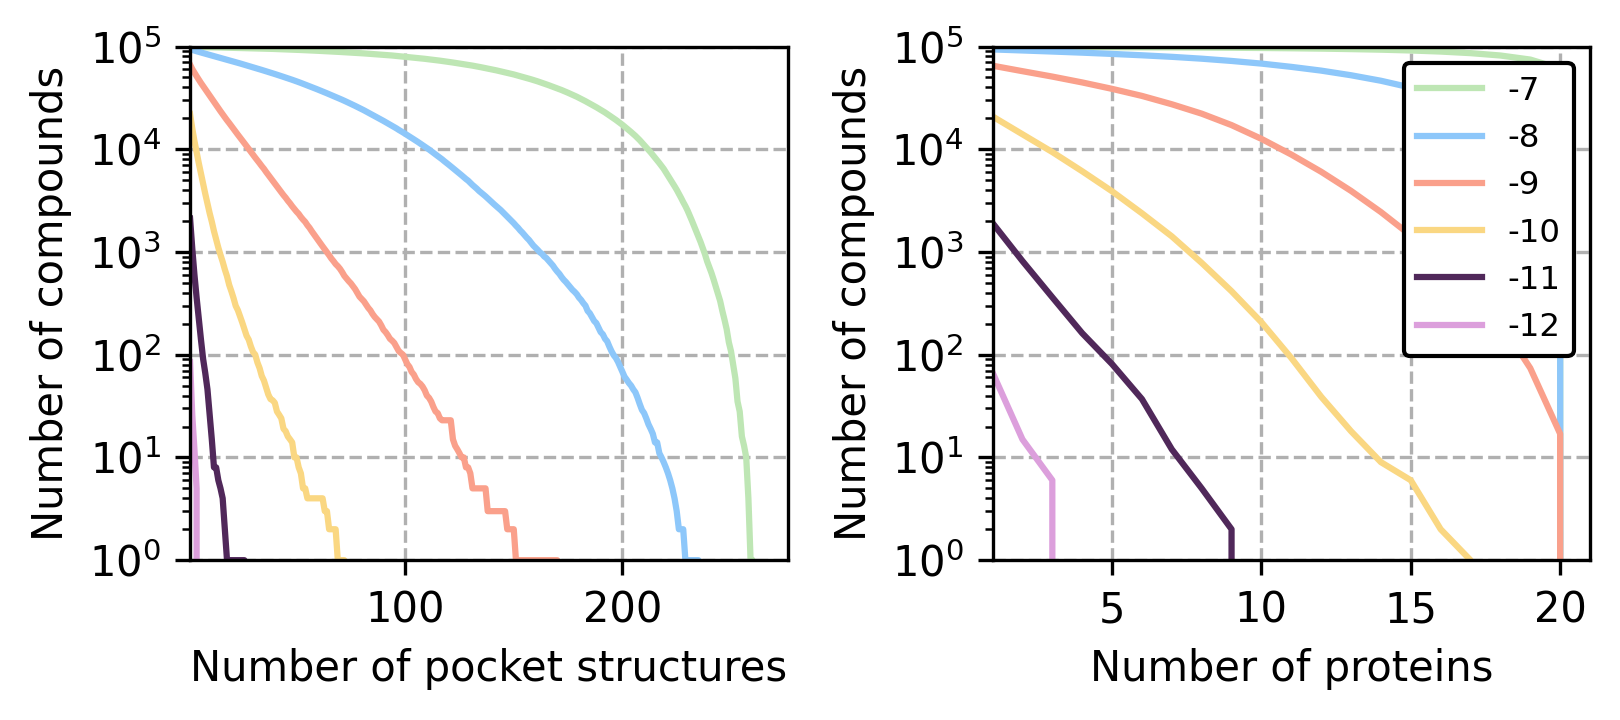

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300)

COLORS= ['#DC9FDC', '#50285A', '#FAD782', '#FAA08B', '#8DC7FA', '#BEE6B4'][::-1]
for score, color in zip(SCORES, COLORS):
    ax[0].plot(n_structures, y_pockets[score], label=str(score), c=color)
for score, color in zip(SCORES, COLORS):
    ax[1].plot(n_proteins, y_proteins[score], label=str(score), c=color)


ax[0].grid(linestyle='--', zorder=-2)
ax[0].set_xlabel("Number of pocket structures")
ax[0].set_ylabel("Number of compounds")
ax[0].set_yscale('log')
ax[0].set_ylim([1, 100_000])
ax[0].set_xlim([1, 276])
ax[0].set_yticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])

ax[1].grid(linestyle='--', zorder=-2)
ax[1].set_ylabel("Number of compounds")
ax[1].set_xlabel("Number of proteins")
ax[1].set_yscale('log')
ax[1].set_ylim([1, 100_000])
ax[1].set_xlim([1, 21])
ax[1].set_yticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])
ax[1].legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 7.8})

plt.tight_layout()
plt.show()

In [13]:
print(f"Compounds with 10+ pocket_structures at score cut-off -10: {y_pockets[-10][np.where(np.array(n_structures) == 10)[0][0]]}")
print(f"Compounds with 100+ pocket_structures at score cut-off -9: {y_pockets[-9][np.where(np.array(n_structures) == 100)[0][0]]}")
print(f"Compounds with 10+ proteins at score cut-off -10: {y_proteins[-10][np.where(np.array(n_proteins) == 10)[0][0]]}")
print(f"Compounds with 10+ proteins at score cut-off -9: {y_proteins[-9][np.where(np.array(n_proteins) == 10)[0][0]]}")
print(f"Compounds with 2+ proteins at score cut-off -11: {y_proteins[-11][np.where(np.array(n_proteins) == 2)[0][0]]}")
print(f"Compounds with 4+ proteins at score cut-off -11: {y_proteins[-11][np.where(np.array(n_proteins) == 4)[0][0]]}")

Compounds with 10+ pocket_structures at score cut-off -10: 2389
Compounds with 100+ pocket_structures at score cut-off -9: 90
Compounds with 10+ proteins at score cut-off -10: 207
Compounds with 10+ proteins at score cut-off -9: 12621
Compounds with 2+ proteins at score cut-off -11: 816
Compounds with 4+ proteins at score cut-off -11: 162


In [14]:
from rdkit.Chem import Draw
from IPython.display import display

def grid(mols, per_row=6, legends=None, size=(200,200), svg=False):
    if legends is None: legends = [""]*len(mols)
    img = Draw.MolsToGridImage(mols, molsPerRow=per_row, subImgSize=size,
                              legends=legends, useSVG=svg, maxMols=1_000)
    display(img)

In [19]:
# compounds = [i for i in cpd_to_proteins[-11] if len(cpd_to_proteins[-11][i]) > 2]
compounds = [i for i in cpd_to_proteins[-11] if len(cpd_to_proteins[-11][i]) > 9]
compounds_ = [Chem.MolFromSmiles(ID_TO_SMILES[i]) for i in compounds]
len(compounds)

2

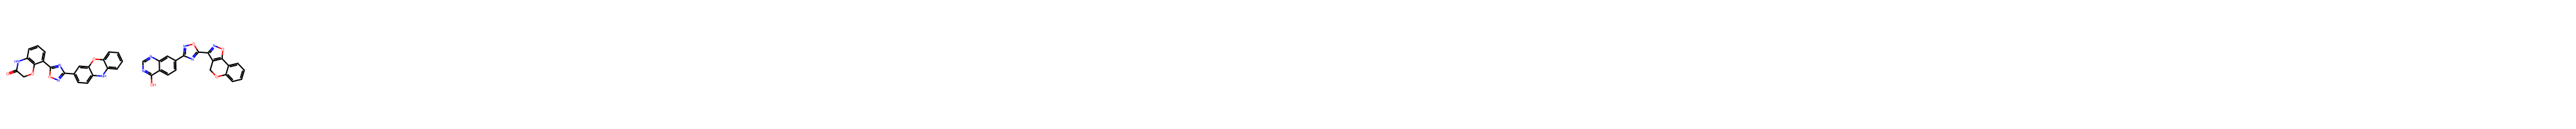

In [20]:
grid(compounds_, per_row=20)

In [25]:
import random
random.seed(32)
random_compounds = random.sample(COMPOUNDS, 10)

In [22]:
def pick_pockets(pocket_to_scores, score_cutoff, N=8):
    candidates = [[i, i.split("_")[1], pocket_to_scores[i]] for i in pocket_to_scores if pocket_to_scores[i] < score_cutoff]
    candidates = sorted(candidates, key=lambda x: x[2])
    best_per_protein = {}
    for pocket, protein, score in candidates:
        if protein not in best_per_protein or score < best_per_protein[protein][1]:
            best_per_protein[protein] = [pocket, score]
    top = [i for i in candidates if best_per_protein[i[1]][0] == i[0]]
    rest = [i for i in candidates if best_per_protein[i[1]][0] != i[0]]
    selected = top + rest
    return selected[:N]

def pymol_screenshot(pocket, ligand, path_to_docking, path_to_output):

    # Define paths
    path_to_output = os.path.join(path_to_output, ligand)
    os.makedirs(path_to_output, exist_ok=True)
    path_to_docking = os.path.join(path_to_docking, pocket)
    st = os.path.join(path_to_docking, pocket.split("_pocket_")[0] + ".pdbqt")

    # Pymol initialization
    pymol.finish_launching(['pymol','-cq'])
    cmd.reinitialize()
    cmd.bg_color("white")
    cmd.set("ray_opaque_background", 0)

    # Load structure
    cmd.load(st, "structure")
    cmd.util.cbag("structure")
    cmd.set_color("structure_col", [0x8D/255, 0xC7/255, 0xFA/255])
    cmd.color("structure_col", "structure and elem C")

    # Load compound
    with tarfile.open(os.path.join(path_to_docking, "docking.tar.gz"), "r|gz") as tf:
        for member in tf:
            if member.name == f"docking/{ligand}_out.sdf":
                data = tf.extractfile(member).read()
                break
    tmp_sdf = os.path.join(path_to_docking, f"{ligand}_tmp.sdf")
    with open(tmp_sdf, "w") as f:
        f.write(data.decode("utf-8", errors="replace"))
    lig = f"lig_{ligand}"
    cmd.load(tmp_sdf, lig)
    os.remove(tmp_sdf)
    cmd.util.cbag(lig)
    cmd.set_color("ligC_orange", [0xF5/255, 0xA6/255, 0x3A/255])
    cmd.color("ligC_orange", f"{lig} and elem C")

    cmd.hide("everything", "structure")
    cmd.show("cartoon", "structure")
    cmd.set("cartoon_transparency", 0.4, "structure")
    cmd.select("pocket_atoms", f"(structure within 6 of {lig}) and not solvent")
    cmd.show("lines", "pocket_atoms")
    cmd.show("sticks", lig)   
    cmd.orient(lig)
    cmd.zoom(lig, buffer=6)
    cmd.h_add("structure")
    cmd.h_add(lig)

    pairs = []
    pairs += cmd.find_pairs(f"{lig} and donor",    "pocket_atoms and acceptor", mode=1, cutoff=3.5, angle=45)
    pairs += cmd.find_pairs(f"{lig} and acceptor", "pocket_atoms and donor",    mode=1, cutoff=3.5, angle=45)
    pairs = list(dict.fromkeys(pairs))

    cmd.delete("hbonds")
    for a1, a2 in pairs:
        cmd.distance("hbonds", a1, a2)

    try:
        cmd.color("yellow", "hbonds")
        cmd.hide("labels", "hbonds")
    except:
        pass
    cmd.set("dash_width", 2)
    cmd.hide("everything", "elem H")

    cmd.set("ray_shadows", 0)
    cmd.set("ray_trace_mode", 1)
    cmd.png(os.path.join(path_to_output, f"{ligand}_{pocket}.png"), width=2000, height=2000, dpi=300, ray=1)
    out_pdb = os.path.join(path_to_output, f"{ligand}_{pocket}.pdb")
    cmd.save(out_pdb)
    COMMAND = ["pandamap", out_pdb, "--ligand", "UNK", "--output", out_pdb.replace(".pdb", "_pandamap.png")]
    subprocess.run(COMMAND, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
    os.remove(out_pdb)

def zoom_crop(img, zoom=2.0, x=0.5, y=0.5):
        """
        Crop a zoomed-in view around an anchor point.

        Parameters
        ----------
        img : np.ndarray
            Image array (H,W[,C])
        zoom : float
            >1 zooms in (smaller crop). =1 returns original.
        x, y : float
            Anchor point in relative coords [0,1]:
            x=0 left, x=1 right; y=0 top, y=1 bottom.

        Returns
        -------
        cropped : np.ndarray
        """
        if zoom <= 1:
            return img

        h, w = img.shape[:2]
        crop_h = max(1, int(h / zoom))
        crop_w = max(1, int(w / zoom))

        # anchor position in pixels
        cx = int(np.clip(x, 0, 1) * (w - 1))
        cy = int(np.clip(y, 0, 1) * (h - 1))

        # crop box, centered on (cx, cy)
        x0 = cx - crop_w // 2
        y0 = cy - crop_h // 2
        x1 = x0 + crop_w
        y1 = y0 + crop_h

        # shift back into bounds if needed
        if x0 < 0:
            x1 -= x0
            x0 = 0
        if y0 < 0:
            y1 -= y0
            y0 = 0
        if x1 > w:
            x0 -= (x1 - w)
            x1 = w
        if y1 > h:
            y0 -= (y1 - h)
            y1 = h

        x0 = max(0, x0); y0 = max(0, y0)
        return img[y0:y1, x0:x1]

dockingscore_to_color = {-7: "#8DC7FA", -8: "#AA96FA", -9: "#DC9FDC", -10: "#FAA08B", -11: "#FAD782"}

uniprot_ids = ["P9WFW5","P9WFW7","P9WFW3","P9WQA1","P9WN61","P9WFT5","P9WFV3","P9WFS9","P9WFV1","P9WFV9","P9WFT9","P9WFV7","P9WFT7","P9WFW1",
               "P9WFU5","P9WFU9","P9WFV5","P9WFT3","P9WFU3","P9WFU1","P9WFT1"]

domain_to_code = {"Other too broad/unspecified functional entities": "Other", "Catalytic Domain (ATP Binding Site)": "CAT", "Anticodon Binding Domain": "ABD", "Editing Domain": "ED", 
                  "tRNA Binding Domain": "tRNA-BD", "Other": "Other", "NA": "NA"}

palette = list(plt.get_cmap("tab20").colors) + [plt.get_cmap("tab20b").colors[0]]
uniprot_to_color = {uid: to_hex(palette[i]) for i, uid in enumerate(uniprot_ids)}
domain_codes = ["Other", "CAT", "ABD", "ED", "tRNA-BD", "NA"]

set2 = list(plt.get_cmap("Set2").colors)
domaincode_to_color = {
    "Other":  to_hex(set2[0]),
    "CAT":    to_hex(set2[1]),
    "ABD":    to_hex(set2[2]),
    "ED":     to_hex(set2[3]),
    "tRNA-BD":to_hex(set2[4]),
    "NA":     "#FFFFFF"}

domainlabel_to_color = {k: domaincode_to_color[v] for k, v in domain_to_code.items()}
confidence_to_color = {'NA': 'white', 'LR': 'firebrick', 'MR': 'darkorange', 'HR': 'forestgreen'}

# Pocket to Interpro domains
pocket_to_domain = defaultdict(list)
for st, pocket_number, interpro in pocket_detection_data_interpro[['File name', 'Pocket number', 'Interpro curated annotation']].values:
    pocket_to_domain[f"{st.replace('.pdb', '')}_pocket_{pocket_number}"].append(interpro)

In [26]:
compounds

['m_270196____17567838____8779148', 'm_270196____8770926____26701300']

In [28]:
random_compounds[:3]

['m_272610____28787410____28807608',
 's_11____22177936____2910108',
 'm_281630____27185830____21619570____20772846']

In [29]:
SCORE_CUTOFF = -7

for COMPOUND_ID in tqdm(["m_270196____17567838____8779148", "m_270196____8770926____26701300", "m_272610____28787410____28807608"]):

    # Get mol
    # COMPOUND_ID = "Z185389718"
    mol = Chem.MolFromSmiles(ID_TO_SMILES[COMPOUND_ID])
    mw = round(Descriptors.MolWt(mol), 3)
    logp = round(Crippen.MolLogP(mol), 3)
    qed_score = round(qed(mol), 3)

    # For that pocket, get mapping pocket to scores
    pocket_to_scores = {pocket: DOCKING_RESULTS_REAL_2[pocket][COMPOUND_ID] for pocket in POCKETS}

    # Get ranks for that compound
    RANKS = []
    RANKS_DICT = {}
    for pocket in sorted(DOCKING_RESULTS_REAL_2):
        values = [DOCKING_RESULTS_REAL_2[pocket][cpd] for cpd in DOCKING_RESULTS_REAL_2[pocket]]
        value = DOCKING_RESULTS_REAL_2[pocket][COMPOUND_ID]
        ranks = sum([i < value for i in values])
        RANKS.append(ranks)
        RANKS_DICT[pocket] = ranks

    # Order pockets to visualize (smart sorting)
    selected = pick_pockets(pocket_to_scores, SCORE_CUTOFF, N=8)

    # Create output directory
    PATH_TO_OUTPUT = os.path.join(root, "..", "processed", "unidock_REAL_docking_2", "docking_snapshots")

    for pocket, protein, score in selected:
        
        pymol_screenshot(pocket, COMPOUND_ID, PATH_TO_DOCKING_RESULTS_REAL_2, PATH_TO_OUTPUT)

    #############################################
    ###########      CREATE IMAGE 1    ##########
    #############################################

    fig, axes = plt.subplots(2, 5, figsize=(20, 8), dpi=300)
    axes = axes.ravel()

    for ax, (pocket, protein, score) in zip(axes[[1,2,3,4,6,7,8,9]], selected):
        file = os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_{pocket}.png")
        ax.imshow(mpimg.imread(file), interpolation='none', resample=False)
        ax.set_xticks([])
        ax.set_yticks([])
        gene = uniprot_to_gene[protein]
        handle = Line2D([0], [0], marker='o', color='w',label= f"{gene} ({protein})", markerfacecolor=uniprot_to_color[protein], markersize=10, markeredgecolor='k')
        leg1 = ax.legend(handles=[handle], loc="upper left", framealpha=1,fontsize=10, edgecolor='k', handletextpad=0)
        ax.add_artist(leg1)
        score_low = min([i for i in dockingscore_to_color if i > score])
        handle = Line2D([0], [0], marker='o', color='w',label=f"Docking score: {score}", markerfacecolor=dockingscore_to_color[score_low], markersize=10, markeredgecolor='k')
        leg2 = ax.legend(handles=[handle], loc="lower left", framealpha=1,fontsize=10, edgecolor='k', handletextpad=0)
        ax.add_artist(leg2)
        domains = set(sorted([domain_to_code[i] for i in pocket_to_domain[pocket]]))
        if len(domains) == 0: domains = ['NA']
        domain_handles = [Line2D([0], [0], marker='o', color='w', label=d, markerfacecolor=domaincode_to_color[d], markersize=10, markeredgecolor='k', linestyle='None') for d in domains]
        leg3 = ax.legend(handles=domain_handles, loc="upper right", framealpha=1, fontsize=10, edgecolor='k', handletextpad=0)
        ax.add_artist(leg3)
        # Robustness
        same_pockets = sorted(set(RESULTS[((RESULTS['pocket1'] == pocket) | (RESULTS['pocket2'] == pocket)) & (RESULTS['same_pocket'] == True)][['pocket1', 'pocket2']].values.flatten()))
        same_pockets_ranks = [RANKS_DICT[p] for p in same_pockets]
        if len(same_pockets_ranks) >= 3:
            if max(same_pockets_ranks) - min(same_pockets_ranks) < 10_000:
                con = 'HR'
            elif max(same_pockets_ranks) - min(same_pockets_ranks) < 20_000:
                con = 'MR'
            else:
                con = 'LR'
        else:
            con = 'NA'
        con_handle = Line2D([0], [0], marker='o', color='w',label=con, markerfacecolor=confidence_to_color[con], markersize=10, markeredgecolor='k')
        leg4 = ax.legend(handles=[con_handle], loc="lower right", framealpha=1, fontsize=10, edgecolor='k', handletextpad=0)
        ax.add_artist(leg4)

    ax = axes[0]
    mol_img = Draw.MolToImage(mol, size=(300, 300))
    ax.imshow(np.asarray(mol_img))
    ax.axis("off")
    text1 = f"Compound ID: {COMPOUND_ID}\nLibrary: Enamine DL HLL-100"
    ax.text(0.5, 0.95, text1, transform=ax.transAxes, ha="center", va="top",fontsize=10, bbox=dict(alpha=0))
    text2 = f"MW: {mw} - logp: {logp} - QED: {qed_score}"
    text2 += f"\nRank (avg ± std): {round(np.mean(RANKS)/1_000, 1)}k ± {round(np.std(RANKS)/1_000, 1)}k"
    text2 += f"\nRank perc. (0.1|0.5|0.9): {round(np.percentile(RANKS, 10))} | {round(np.percentile(RANKS, 50))} | {round(np.percentile(RANKS, 90))}"
    ax.text(0.5, 0.1, text2, transform=ax.transAxes, ha="center", va="top",fontsize=10, bbox=dict(alpha=0))

    ax = axes[5]
    scores_to_visualize = [-11, -10, -9, -8, -7]
    ax.set_xticks([i for i in range(len(scores_to_visualize))], scores_to_visualize)
    ax.set_ylim([0, 21])
    ax.grid(linestyle='--', zorder=-2)
    ax.set_ylabel("Number of protein targets")
    ax.set_xlabel("Docking score")
    ax.set_yticks([0, 5, 10, 15, 20])
    for c, score in enumerate(scores_to_visualize):
        ax.bar(c, 21, color="#D2D2D2", edgecolor='k', zorder=2)
        ax.bar(c, len(cpd_to_proteins[score][COMPOUND_ID]), color=dockingscore_to_color[score], edgecolor='k', zorder=2)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_ALL.png"), dpi=600)
    # plt.show()
    plt.close(fig)
    

    #############################################
    ###########      CREATE IMAGE 2    ##########
    #############################################


    fig, axes = plt.subplots(2, 5, figsize=(20, 8), dpi=300)
    axes = axes.ravel()

    for ax, (pocket, protein, score) in zip(axes[[1,2,3,4,6,7,8,9]], selected):
        file = os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_{pocket}_pandamap.png")
        img = mpimg.imread(file)
        img_zoomed = zoom_crop(img, x=0.5, y=0.51, zoom=1.17)
        ax.imshow(img_zoomed, interpolation='none')
        ax.set_xticks([])
        ax.set_yticks([])
        rect = patches.Rectangle((0.8, 0.85), 0.5, 0.5, transform=ax.transAxes, facecolor='w', edgecolor='w', zorder=2)
        ax.add_patch(rect)

    ax = axes[5]
    img = mpimg.imread(os.path.join(PATH_TO_OUTPUT, "template_pandamap.png"))
    ax.imshow(img, interpolation="none")
    ax.axis("off")

    ax = axes[0]
    mol_img = Draw.MolToImage(mol, size=(300, 300))
    ax.imshow(np.asarray(mol_img))
    ax.axis("off")
    text1 = f"Compound ID: {COMPOUND_ID}\nLibrary: Enamine DL HLL-100"
    ax.text(0.5, 0.95, text1, transform=ax.transAxes, ha="center", va="top",fontsize=10, bbox=dict(alpha=0))
    text2 = f"MW: {mw} - logp: {logp} - QED: {qed_score}"
    text2 += f"\nRank (avg ± std): {round(np.mean(RANKS)/1_000, 1)}k ± {round(np.std(RANKS)/1_000, 1)}k"
    text2 += f"\nRank perc. (0.1|0.5|0.9): {round(np.percentile(RANKS, 10))} | {round(np.percentile(RANKS, 50))} | {round(np.percentile(RANKS, 90))}"
    ax.text(0.5, 0.1, text2, transform=ax.transAxes, ha="center", va="top",fontsize=10, bbox=dict(alpha=0))


    plt.tight_layout()
    plt.savefig(os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_ALL_pandamap.png"), dpi=600)
    # plt.show()
    plt.close(fig)

    # Remove tmp files
    for pocket, protein, score in selected:
        os.remove(os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_{pocket}_pandamap.png"))
        os.remove(os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_{pocket}.png"))

100%|██████████| 3/3 [03:51<00:00, 77.14s/it]
